
# Train Soccer Player Detector

---

[![Download Dataset](https://app.roboflow.com/images/download-dataset-badge.svg)](https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc)

This notebook is based on the [How to Train YOLOv8 Object Detection on a Custom Dataset](https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb) notebook from the [roboflow/notebooks](https://github.com/roboflow/notebooks) repository.

## Configure API keys

- Open your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Fri Mar 20 17:23:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install dependencies

In [3]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.6 MB/s eta 0:00:00


## Imports

In [4]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

## Pull dataset

In [5]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
version = project.version(10)
dataset = version.download("yolov8")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-10 in yolov8:: 100%|██████████| 636/636 [00:00<00:00, 2838.05it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


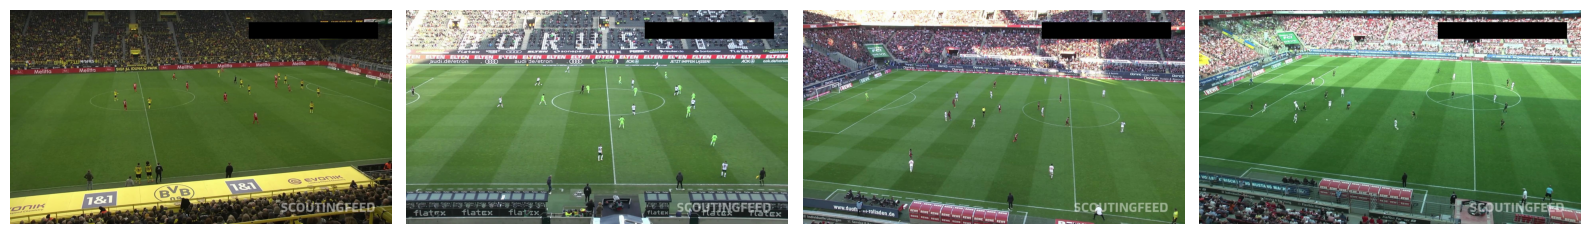

In [13]:
import matplotlib.pyplot as plt
import random
import glob

# Get the path to the training images
train_images_path = f"{dataset.location}/train/images/*"

all_images = glob.glob(train_images_path)

selected_images = random.sample(all_images, 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, img_path in enumerate(selected_images):
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**NOTE:** Update `data.yaml` structure to align with the latest requirements of the `ultralytics` package.



In [6]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

## Custom training

In [7]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8x.pt data={dataset.location}/data.yaml batch=6 epochs=50 imgsz=1280 plots=True

/content
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/football-players-detection-10/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

In [8]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1680.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch1681.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch1682.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg     weights
labels.jpg			 train_batch2.jpg


/content


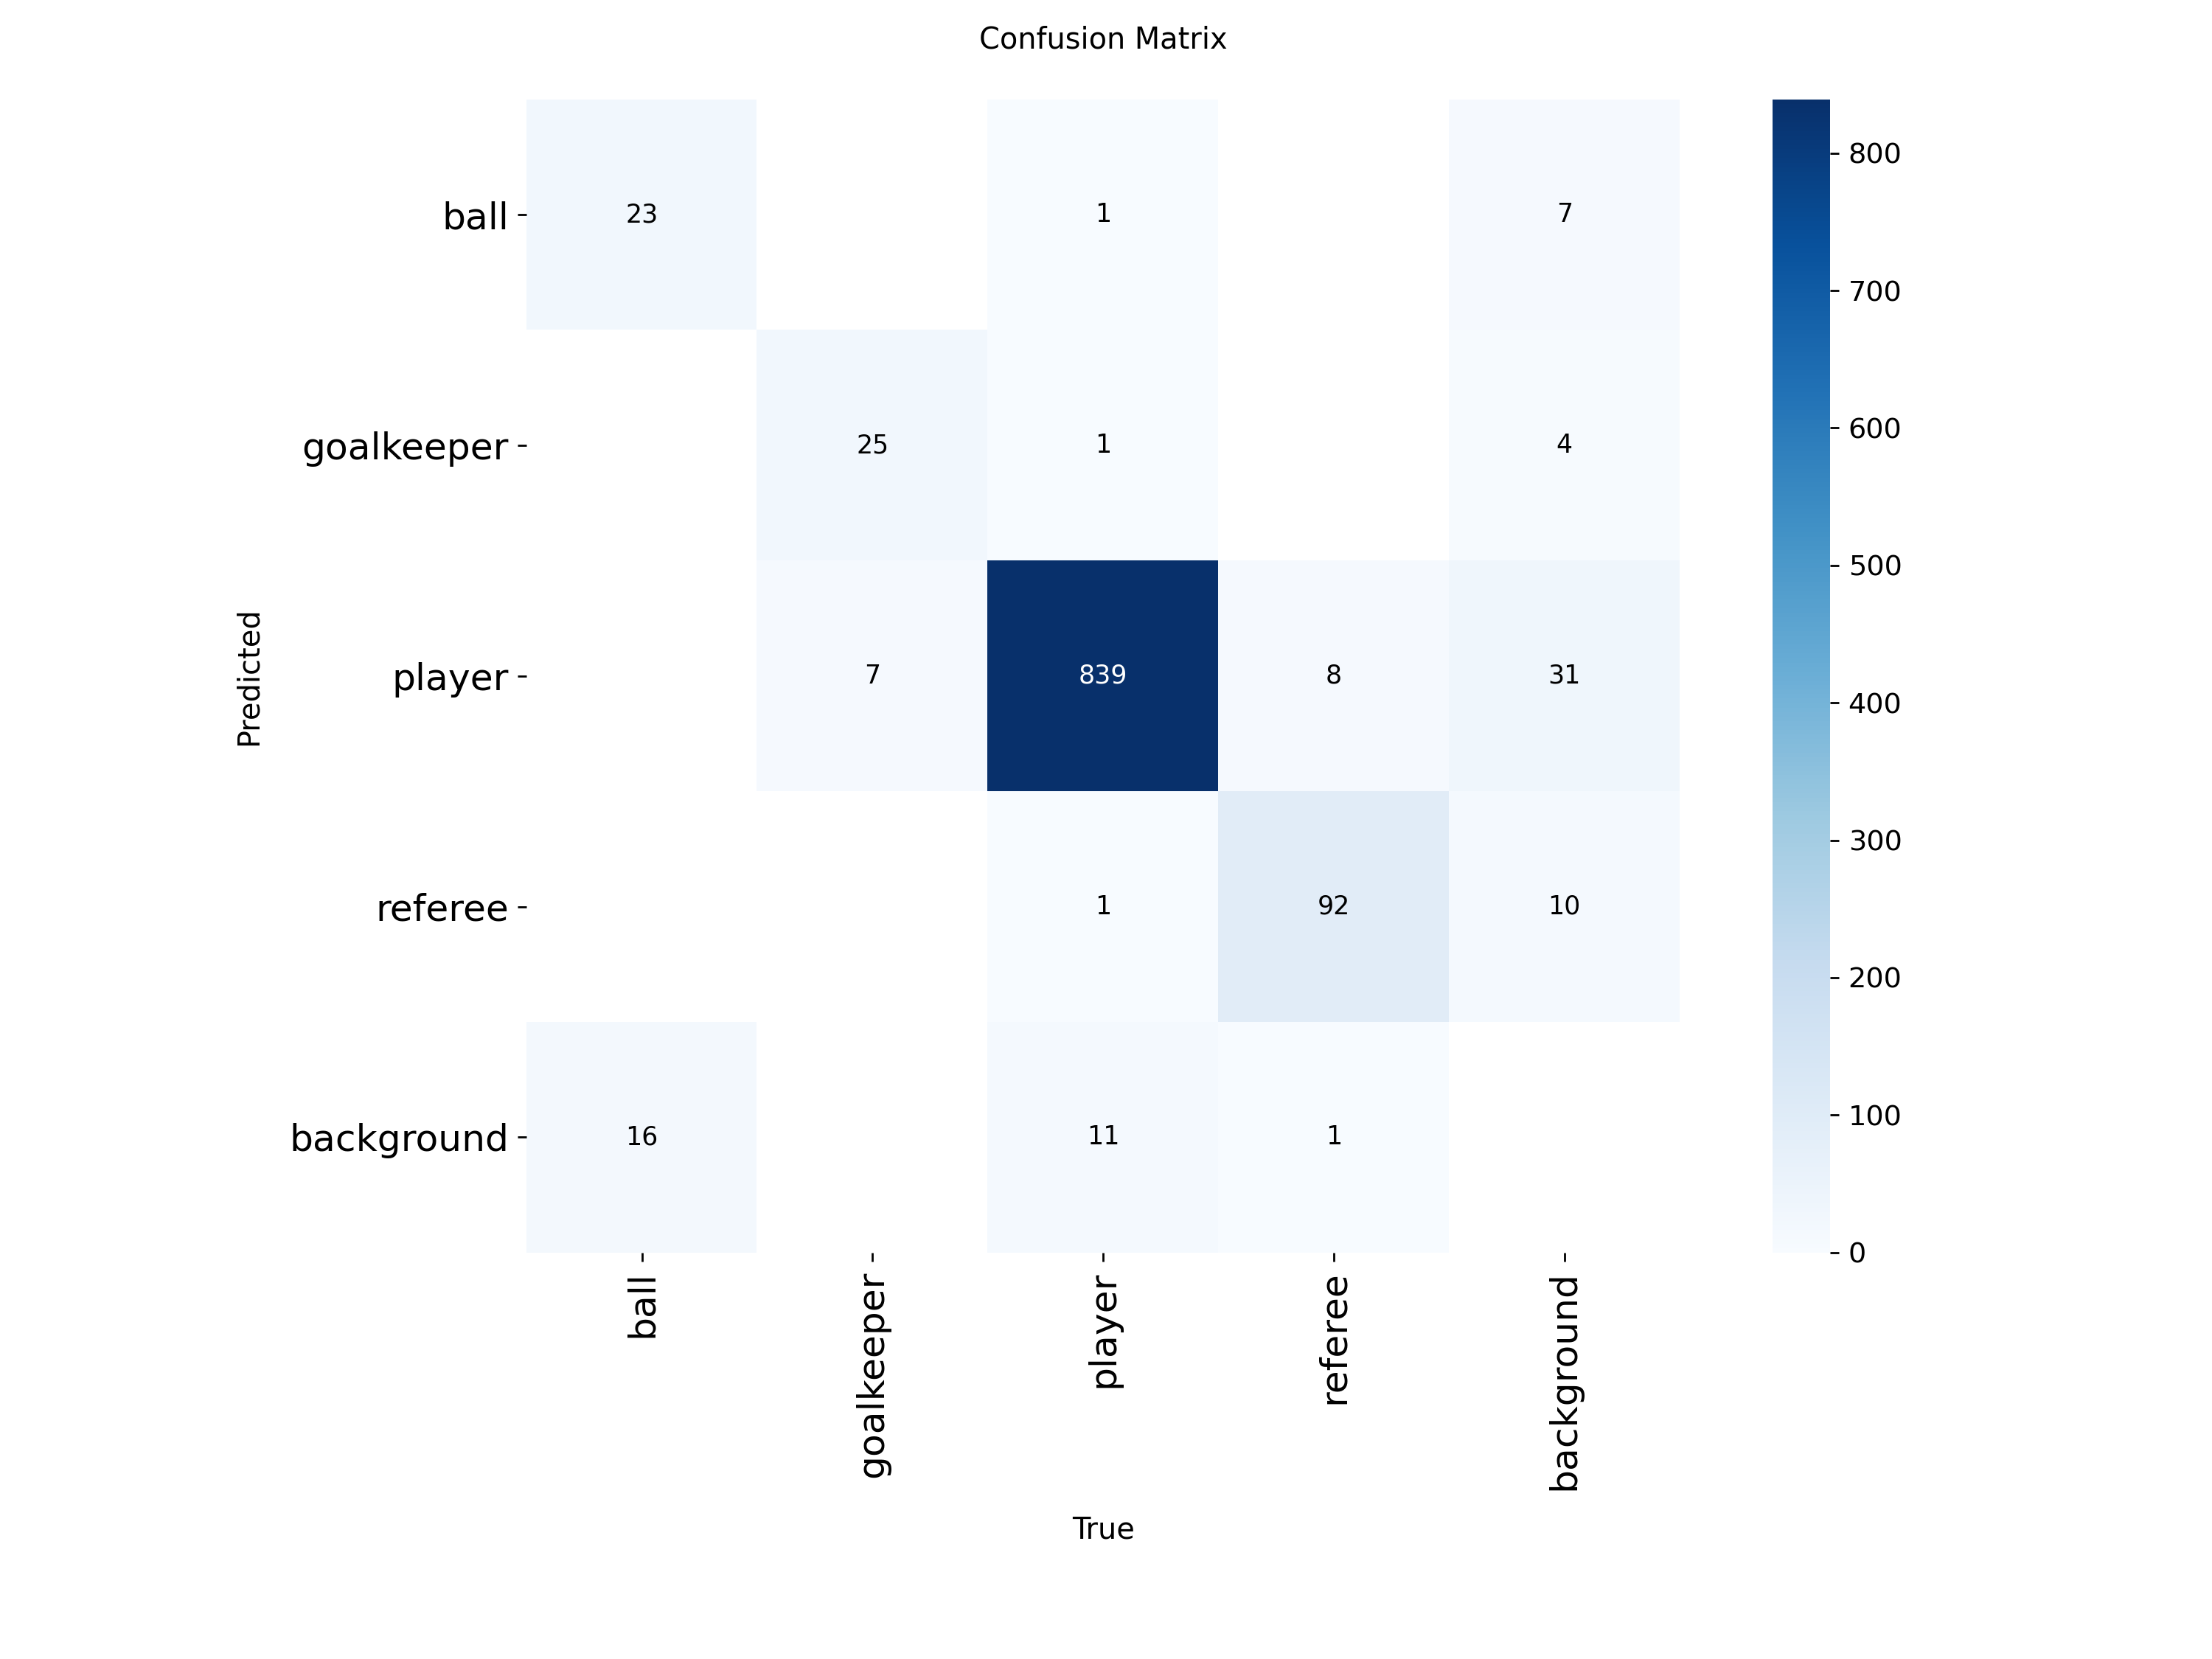

In [9]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


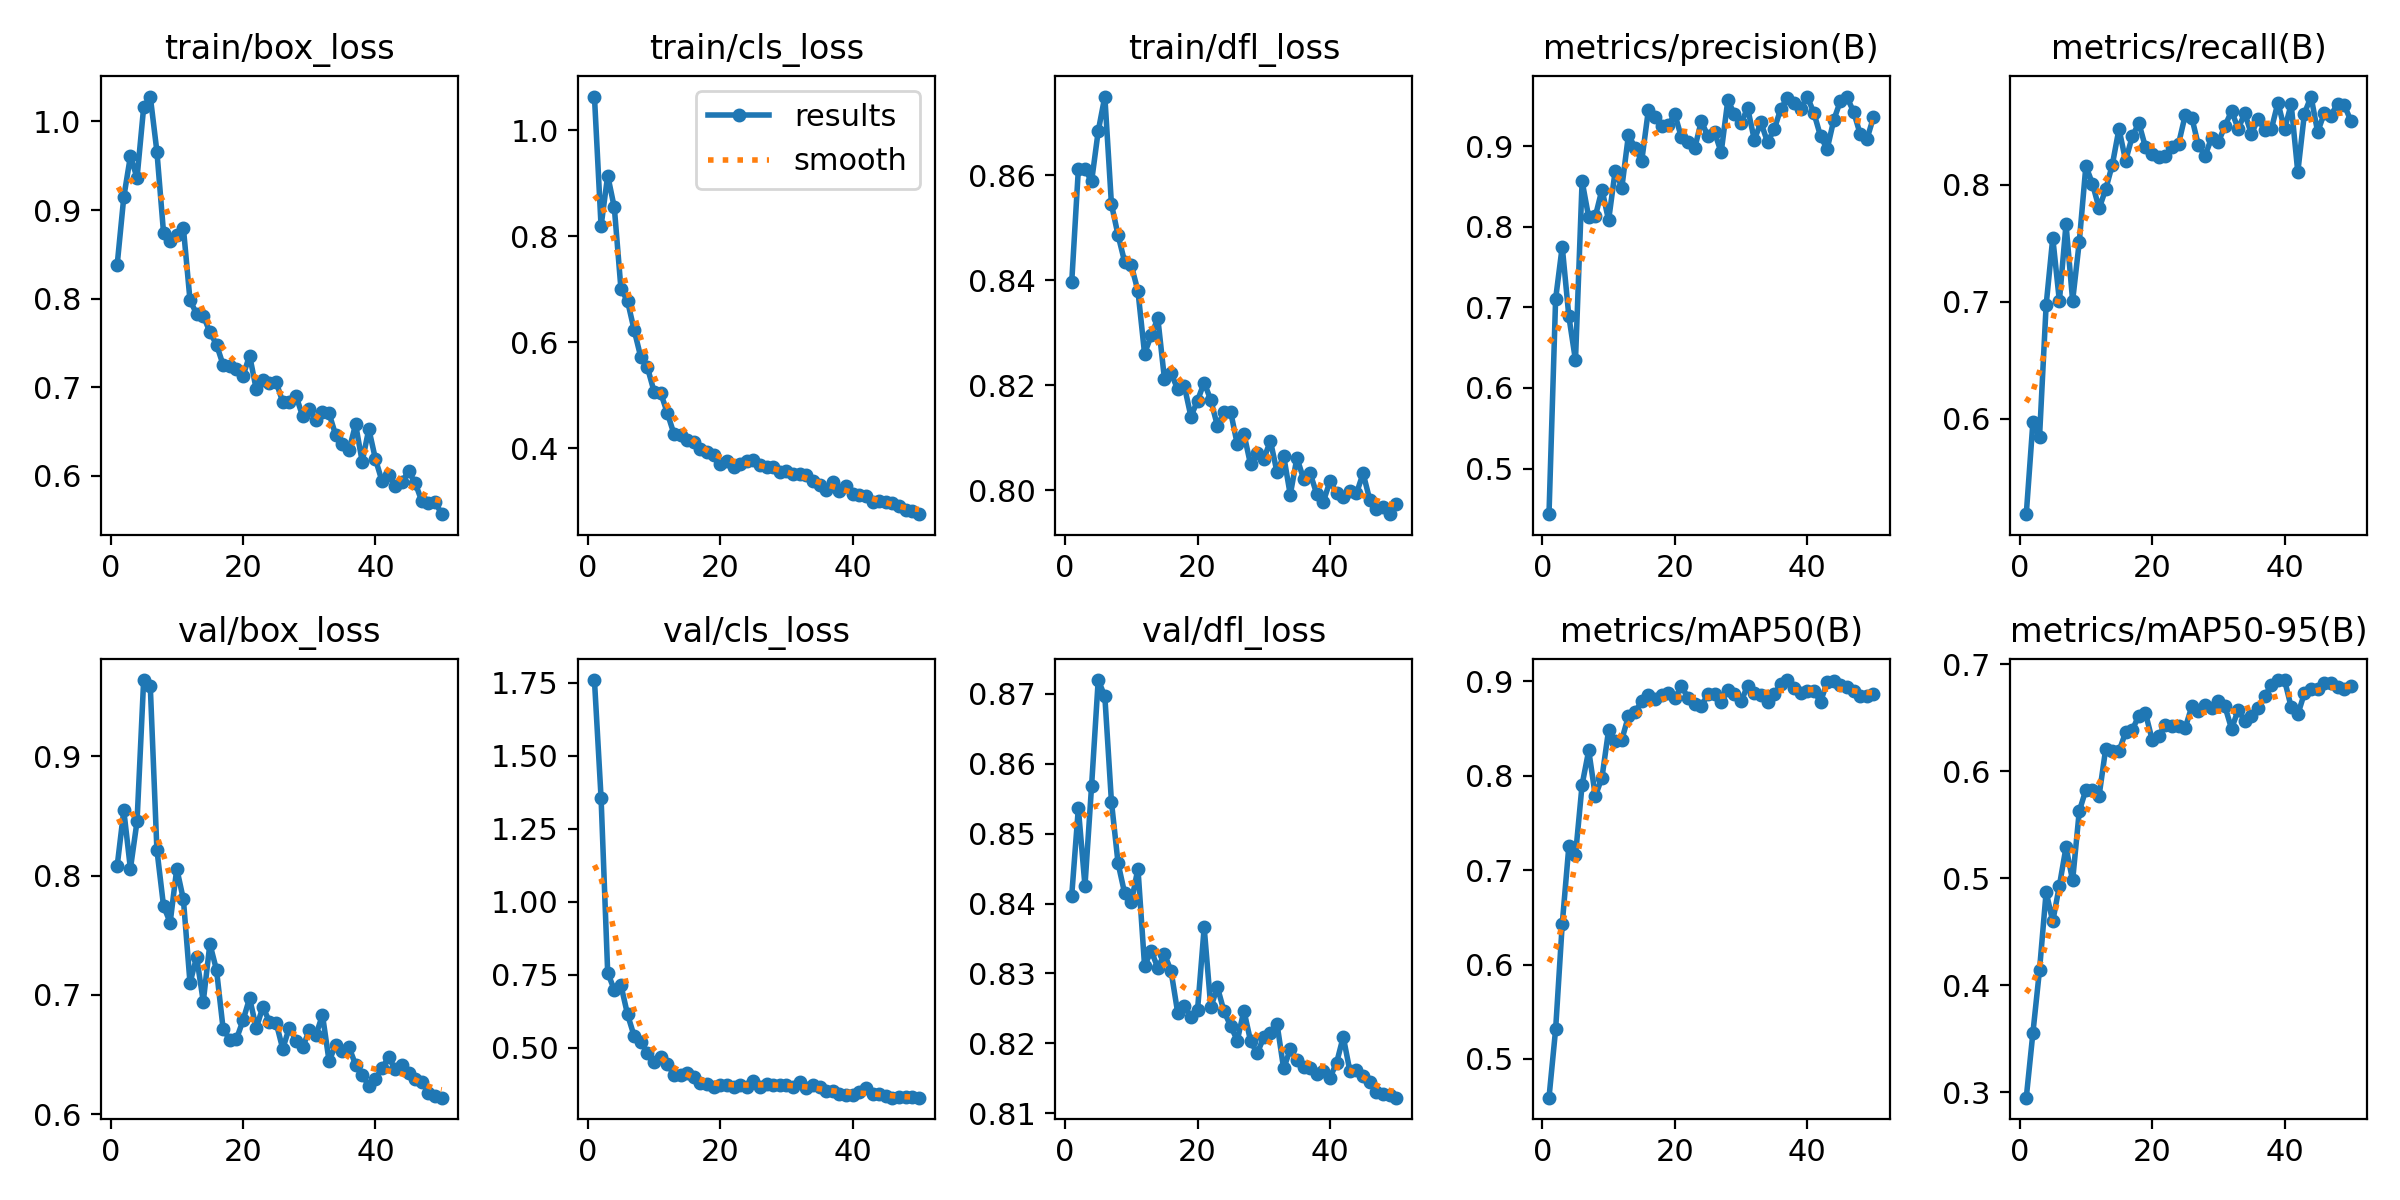

In [10]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


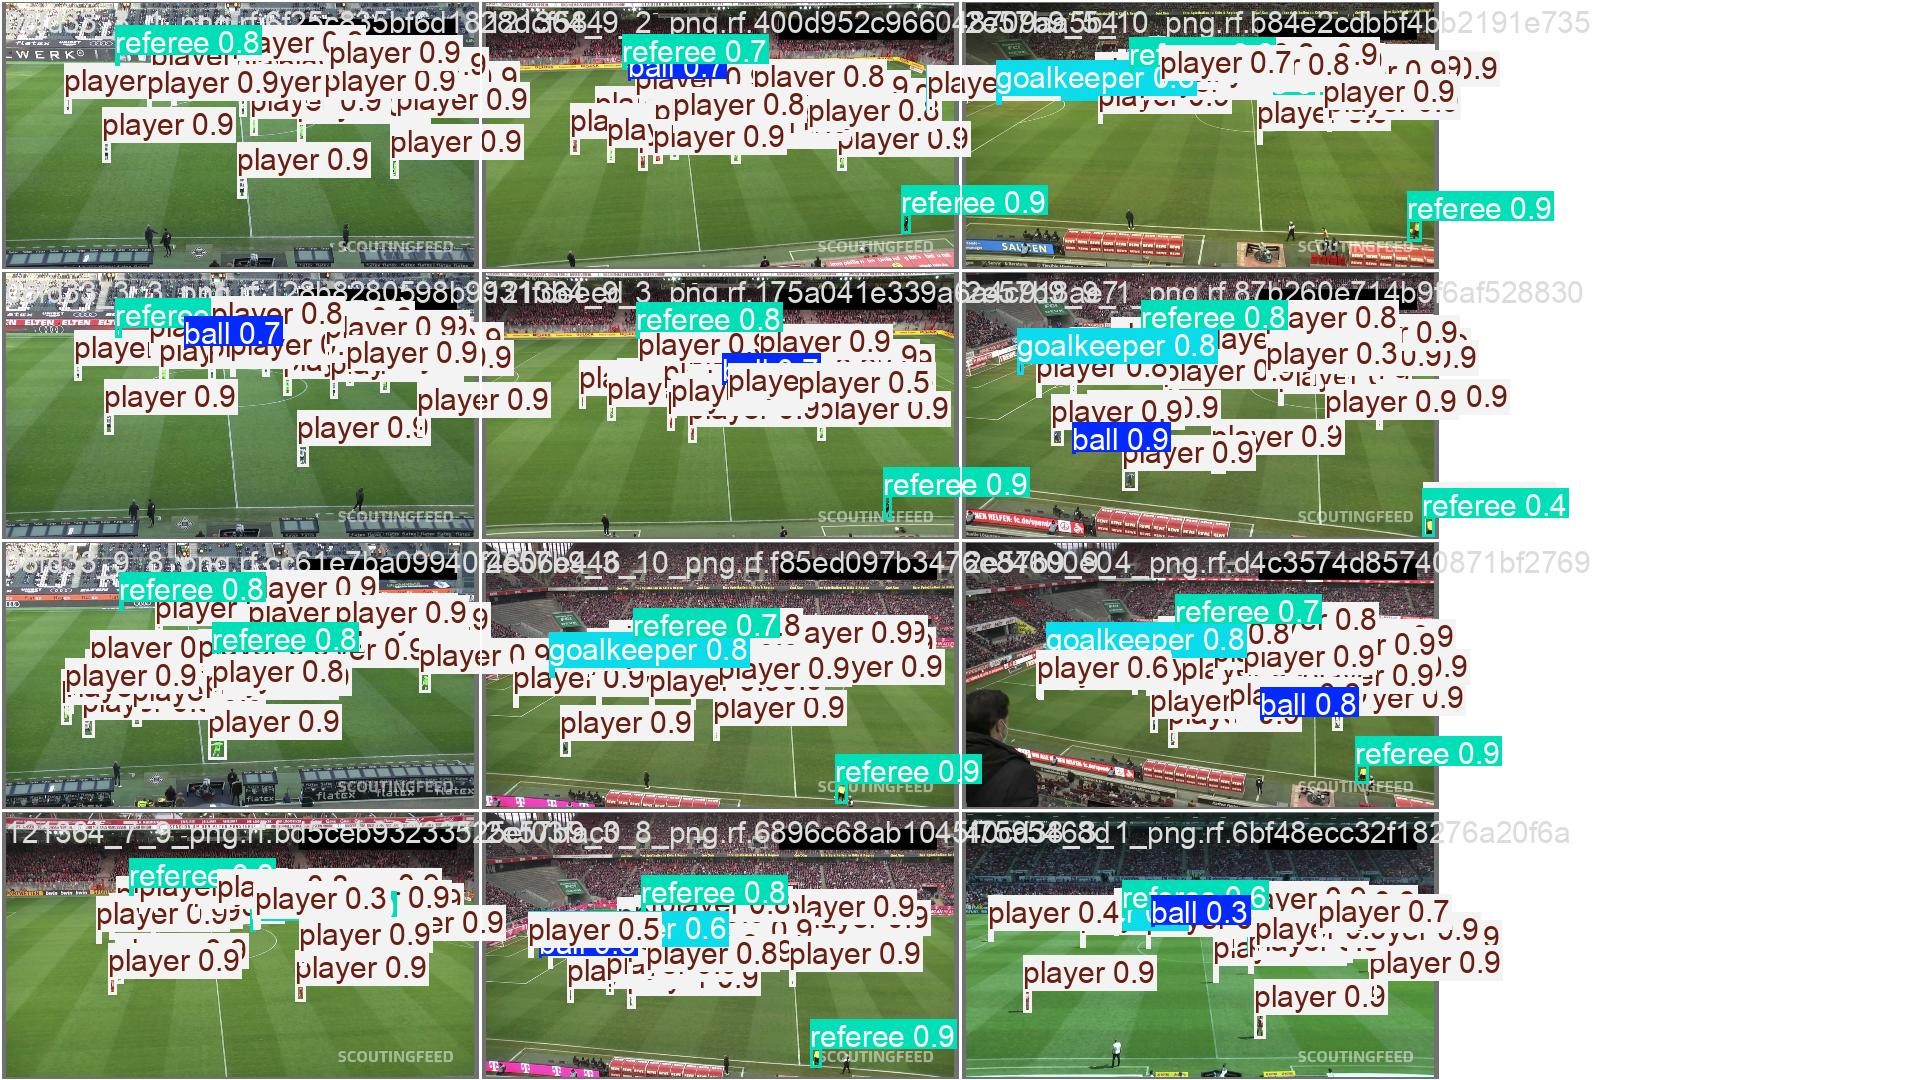

In [11]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate custom model

In [12]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml imgsz=1280

/content
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 68,127,420 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3400.2±919.2 MB/s, size: 235.8 KB)
val: Scanning /content/datasets/football-players-detection-10/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 7.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.6s/it 7.7s
                   all         43       1025       0.96      0.847      0.889      0.701
                  ball         39         39      0.931       0.59      0.619       0.36
            goalkeeper         32         32      0.965      0.857      0.962      0.827
                player         43        853       0.97      0.982      0.991      0.866
               referee         43        101      0.976       0.96      0.985      0.751
Speed: 15.

In [14]:
!zip -r best_model_weights.zip {HOME}/runs/detect/train/weights/best.pt

from google.colab import files
files.download('best_model_weights.zip')

  adding: content/runs/detect/train/weights/best.pt (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Check Inference on test images

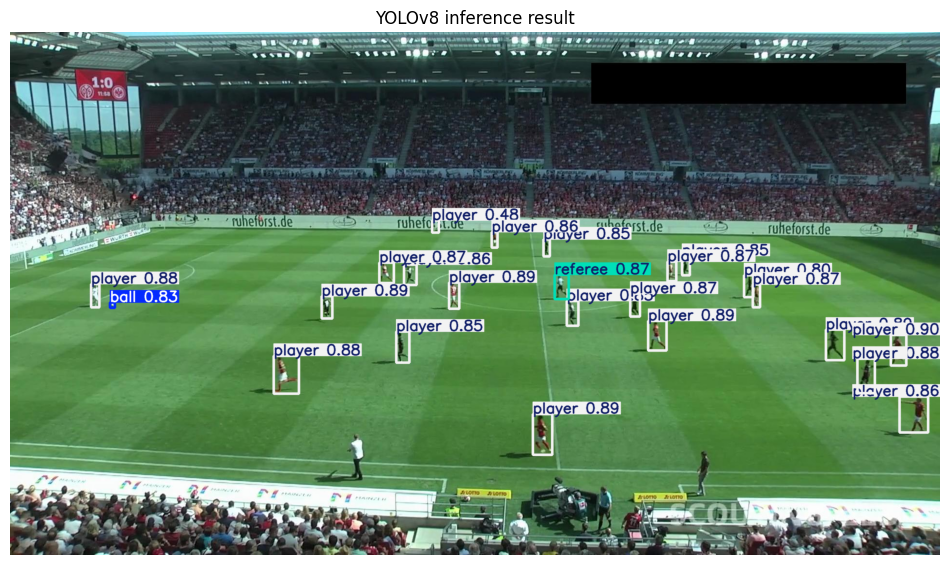

In [7]:
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Path to your fine-tuned weights
MODEL_PATH = Path("best_model_weights/content/runs/detect/train/weights/best.pt")

# Single image path
IMAGE_PATH = Path(r"C:\Users\lolen\Downloads\Jupyter Mac\Football Viz\Github_Work\Football-Viz-for-Twitter\Projects\Computer Vision\Roboflow\data\test\t2.jpg")

# Annotation styling
FONT_SIZE = 22       # increase/decrease label text size
LINE_WIDTH = 3       # increase/decrease bounding box thickness
FONT_FILE = "Arial.ttf"  # any available .ttf font file

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH.resolve()}")
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

model = YOLO(str(MODEL_PATH))
results = model.predict(source=str(IMAGE_PATH), conf=0.25, imgsz=1280, verbose=False)

annotated = results[0].plot(
    font_size=FONT_SIZE,
    line_width=LINE_WIDTH,
    font=FONT_FILE,
    labels=True,
    boxes=True
    )

plt.figure(figsize=(12, 8))
plt.imshow(annotated[:, :, ::-1])  # BGR -> RGB
plt.axis("off")
plt.title("YOLOv8 inference result")
plt.show()

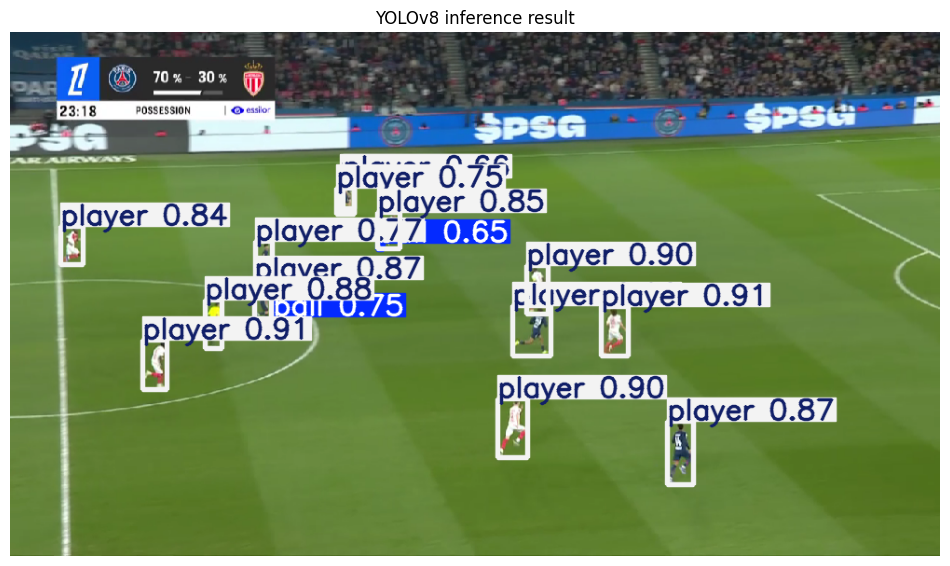

In [9]:
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Path to your fine-tuned weights
MODEL_PATH = Path("best_model_weights/content/runs/detect/train/weights/best.pt")

# Single image path
IMAGE_PATH = Path(r"C:\Users\lolen\Downloads\Jupyter Mac\Football Viz\Github_Work\Football-Viz-for-Twitter\Projects\Computer Vision\Roboflow\data\test\t3.png")

# Annotation styling
FONT_SIZE = 22       # increase/decrease label text size
LINE_WIDTH = 3       # increase/decrease bounding box thickness
FONT_FILE = "Arial.ttf"  # any available .ttf font file

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH.resolve()}")
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

model = YOLO(str(MODEL_PATH))
results = model.predict(source=str(IMAGE_PATH), conf=0.25, imgsz=1280, verbose=False)

annotated = results[0].plot(
    font_size=FONT_SIZE,
    line_width=LINE_WIDTH,
    font=FONT_FILE,
    labels=True,
    boxes=True
    )

plt.figure(figsize=(12, 8))
plt.imshow(annotated[:, :, ::-1])  # BGR -> RGB
plt.axis("off")
plt.title("YOLOv8 inference result")
plt.show()